In [ ]:
# first vivit but without traps
import numpy as np
import matplotlib.pyplot as plt

# Grid size
K = 12
gamma = 0.95

START = (0, 0)
GOAL = (K-1, K-1)

ACTIONS = {
    0: (-1, 0),  # North
    1: (1, 0),   # South
    2: (0, 1),   # East
    3: (0, -1),  # West
}

def is_valid(state): #Actions that go out of bounds are forbidden (0.k)
    x, y = state
    return 0 <= x < K and 0 <= y < K

def step(state, action):
    if state == GOAL: # If you are already at the goal:you stay there forever
        return state, 0

    dx, dy = ACTIONS[action] #Computing next state . where system wants to go
    next_state = (state[0] + dx, state[1] + dy)

    if not is_valid(next_state):
        next_state = state  # if try to leave the grid → stay but still gets punished -1

    if next_state == GOAL: #if next step is reaching the goal
        reward = 2 * (K - 1)
    else:
        reward = -1

    return next_state, reward





In [ ]:
#This is the behavior policy used to generate episodes.


def epsilon_greedy_policy(Q, state, epsilon):
    if np.random.rand() < epsilon: #With probability ε → explore (random action)

        return np.random.choice(list(ACTIONS.keys()))
    else: #With probability 1−ε → exploit (best known action)

        x, y = state
        return np.argmax(Q[x, y])


In [ ]:
def generate_episode_mc(Q, epsilon, max_steps=500):
    episode = []
    state = START
    steps = 0

    while state != GOAL and steps < max_steps:
        action = epsilon_greedy_policy(Q, state, epsilon)
        next_state, reward = step(state, action)#Apply the environment dynamics (step)
        episode.append((state, action, reward))#Store (state, action, reward)
        state = next_state #Move to the next state
        steps += 1

    return episode


In [ ]:


Q = np.zeros((K, K, len(ACTIONS))) #→ estimated expected return from state s taking action a
N = np.zeros((K, K, len(ACTIONS)))  # visit counts - number of times (s,a) has been updated

for ep in range(episodes):

    episode = generate_episode_mc(Q, epsilon) #Generate one full episode and Then learn from it
    G = 0
    visited = set()

    for t in reversed(range(len(episode))): #returns are computed backward after the episode terminates.
        state, action, reward = episode[t]
        x, y = state
        G = gamma * G + reward

        # FIRST-VISIT MONTE CARLO
        if (state, action) not in visited:
            visited.add((state, action))
            N[x, y, action] += 1   #Q(s,a)=N(s,a)1​i=1∑N(s,a)​Gi     This avoids storing all returns while preserving the Monte-Carlo expectation.
            Q[x, y, action] += (G - Q[x, y, action]) / N[x, y, action]


In [ ]:
policy_mc = np.zeros((K, K), dtype=int)

for x in range(K):
    for y in range(K):
        if (x, y) == GOAL:
            continue
        policy_mc[x, y] = np.argmax(Q[x, y])

        #Policy evaluation (via MC returns) and policy improvement (greedy w.r.t Q)
        #Monte-Carlo policy iteration alternates between policy evaluation using returns and greedy policy improvement.


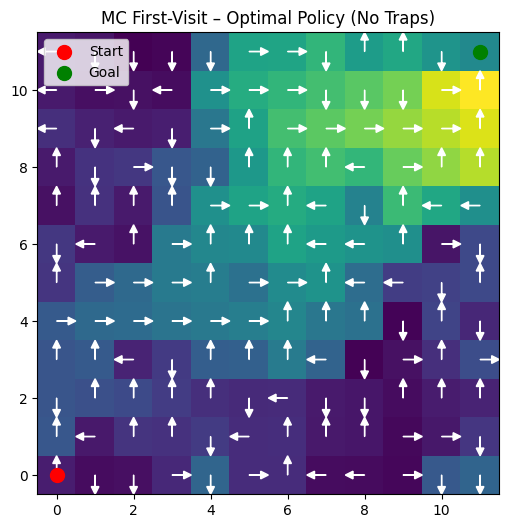

In [ ]:
def plot_policy(V, policy, title):
    plt.figure(figsize=(6, 6))
    plt.imshow(V, origin="lower", cmap="viridis")

    for x in range(K):
        for y in range(K):
            if (x, y) == GOAL:
                continue

            a = policy[x, y]
            dx, dy = ACTIONS[a]

            plt.arrow(
                y, x,
                dy * 0.3, dx * 0.3,
                head_width=0.2,
                head_length=0.2,
                color="white"
            )

    plt.scatter(START[1], START[0], c="red", s=100, label="Start")
    plt.scatter(GOAL[1], GOAL[0], c="green", s=100, label="Goal")
    plt.legend()
    plt.title(title)
    plt.show()
plot_policy(np.max(Q, axis=2), policy_mc,
            "MC First-Visit – Optimal Policy (No Traps)")
